# Candidate–Job Matching using Similarity Metrics

## AI for Data Analysis – Final Project

This project explores how text analysis and mathematical similarity measures can support automated
candidate-job matching in recruitment scenarios.

## Introduction

Modern recruitment processes often require evaluating large numbers of candidate CVs against specific technical job requirements.

This project investigates whether text-based similarity analysis can effectively identify relevant and non-relevant candidates by analyzing overlap in technologies, skills, experience, and role requirements.

Using TF-IDF vectorization, the project compares two mathematical similarity approaches:

- Cosine Similarity
- Euclidean Distance

The primary objective is to evaluate how these methods can support recruiter-oriented candidate screening, ranking, and preliminary decision-making processes.

## Problem Definition

Given a collection of candidate CVs and job descriptions, the objective of this project is to:

- transform textual information into numerical representations
- calculate similarity scores between candidates and job roles
- rank candidates based on job relevance
- generate recruiter-oriented screening recommendations

The main challenge is determining whether text-based similarity measures can effectively approximate recruitment relevance and support early-stage candidate screening processes.

## Data Sources

This project uses two independent datasets:

1. Candidate CV profiles
2. Job description profiles

The candidate dataset contains synthetic CV data based on realistic software engineering and technical roles. The job description dataset simulates real-world recruitment requirements across multiple technology domains.

Both datasets were created specifically for similarity analysis and candidate-job matching experiments.

## Technologies Used

The project was developed using the following technologies and libraries:

- Python – main programming language used for data processing and analysis
- pandas – data loading, cleaning, and manipulation
- scikit-learn – TF-IDF vectorization and similarity calculations
- matplotlib – data visualization and graphical analysis
- Jupyter Notebook – interactive project development and documentation environment

## Methodology

The project follows the following workflow:

1. Load and preprocess textual candidate and job description data
2. Clean and normalize the text information
3. Transform textual data into TF-IDF vector representations
4. Calculate similarity scores between candidate profiles and job roles
5. Compare cosine similarity and Euclidean distance approaches
6. Visualize and analyze the similarity results
7. Generate recruiter-oriented screening recommendations based on similarity thresholds

## Mathematical Background

### TF-IDF Vectorization

TF-IDF (Term Frequency – Inverse Document Frequency) is used to transform text documents into numerical feature vectors.

It is defined as:

$$
TF\text{-}IDF(t,d)=TF(t,d)\times\log\left(\frac{N}{DF(t)}\right)
$$

where:

- TF(t,d) is the frequency of term t in document d
- DF(t) is the number of documents containing the term
- N is the total number of documents

TF-IDF gives higher importance to terms that are frequent in a specific document but rare across the dataset.

### Cosine Similarity

Cosine similarity is commonly used in text similarity analysis to measure the similarity between vectorized documents.
It is defined as:

$$
\cos(\theta) =
\frac{A \cdot B}
{\|A\| \|B\|}
$$

where:
- \(A\) and \(B\) are vector representations of text documents
- the numerator represents the dot product
- the denominator normalizes vector magnitude

Higher cosine similarity values indicate stronger similarity between candidate profiles and job descriptions.

### Euclidean Distance

Euclidean distance measures the geometric distance between vectors in multidimensional space.

It is defined as:

$$
d(p,q)=\sqrt{\sum_{i=1}^{n}(p_i-q_i)^2}
$$

Lower Euclidean distance values indicate stronger similarity between candidate and job vectors in multidimensional space.

---

In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [2]:
cv_df = pd.read_csv("cv_data.csv", sep=";")
job_df = pd.read_csv("job_data.csv", sep=";")

In [3]:
cv_df

,id,name,text
0,1,Alexander Petrov,Senior .NET Developer with 7 years experience ...
1,2,Georgi Ivanov,Junior .NET Developer with 1.5 years experienc...
2,3,Nikolay Dimitrov,"Python Developer with Django, FastAPI, Machine..."
3,4,Martina Petrova,Mid .NET Developer with 4 years experience in ...
4,5,Petar Dimitrov,"Java Backend Developer with Spring Boot, Micro..."
5,6,Elena Nikolova,"Frontend Developer with React, TypeScript, Jav..."
6,7,Viktor Iliev,"DevOps Engineer with Docker, Kubernetes, Azure..."
7,8,Maria Georgieva,"QA Automation Engineer with Selenium, Cypress,..."
8,9,Desislava Ivanova,"Product Owner with Agile, Scrum, Jira, stakeho..."
9,10,Kaloyan Vasilev,"Data Analyst with Python, SQL, Power BI, panda..."


In [4]:
job_df

,id,role,text
0,1,Senior .NET Developer,Looking for Senior .NET Developer with 5+ year...
1,2,Python Developer,Looking for Python Developer with 3+ years exp...
2,3,Java Developer,Looking for a Java Backend Developer with expe...
3,4,Mobile Developer,Seeking a Mobile Developer specialized in Andr...
4,5,Cybersecurity Specialist,We are hiring a Cybersecurity Specialist with ...
5,6,Project Manager,Looking for a Project Manager experienced in A...
6,7,Data Scientist,Seeking a Data Scientist with experience in Py...
7,8,QA Automation Engineer,Looking for a QA Automation Engineer experienc...
8,9,Frontend Developer,"Seeking a Frontend Developer skilled in React,..."


### Dataset Overview
The datasets contain candidate CVs and job descriptions used for similarity analysis. 
The CV dataset includes candidate names and profile descriptions, while the job dataset contains role titles and job requirement texts.

In [5]:
cv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      20 non-null     int64 
 1   name    20 non-null     object
 2   text    20 non-null     object
dtypes: int64(1), object(2)
memory usage: 612.0+ bytes


In [6]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      9 non-null      int64 
 1   role    9 non-null      object
 2   text    9 non-null      object
dtypes: int64(1), object(2)
memory usage: 348.0+ bytes


### Missing Values Check

In [7]:
print(cv_df.isnull().sum())
print(job_df.isnull().sum())

id      0
name    0
text    0
dtype: int64
id      0
role    0
text    0
dtype: int64


### Duplicate Records Check

In [8]:
print(cv_df.duplicated().sum())
print(job_df.duplicated().sum())

0
0


### Data Cleaning and Preparation

In [9]:
def preprocess_text(text):
    text = text.lower()
    text = text.replace(".net", "dotnet")
    text = re.sub(r'[^\w\s.]', '', text)
    return text

In [10]:
cv_df["cleaned_text"] = cv_df["text"].apply(preprocess_text)
job_df["cleaned_text"] = job_df["text"].apply(preprocess_text)

In [11]:
cv_df[["text", "cleaned_text"]].head()

,text,cleaned_text
0,Senior .NET Developer with 7 years experience ...,senior dotnet developer with 7 years experienc...
1,Junior .NET Developer with 1.5 years experienc...,junior dotnet developer with 1.5 years experie...
2,"Python Developer with Django, FastAPI, Machine...",python developer with django fastapi machine l...
3,Mid .NET Developer with 4 years experience in ...,mid dotnet developer with 4 years experience i...
4,"Java Backend Developer with Spring Boot, Micro...",java backend developer with spring boot micros...


In [12]:
job_df[["text", "cleaned_text"]].head()

,text,cleaned_text
0,Looking for Senior .NET Developer with 5+ year...,looking for senior dotnet developer with 5 yea...
1,Looking for Python Developer with 3+ years exp...,looking for python developer with 3 years expe...
2,Looking for a Java Backend Developer with expe...,looking for a java backend developer with expe...
3,Seeking a Mobile Developer specialized in Andr...,seeking a mobile developer specialized in andr...
4,We are hiring a Cybersecurity Specialist with ...,we are hiring a cybersecurity specialist with ...


### Prepare Text Data

In [13]:
cv_texts = cv_df["cleaned_text"].tolist()
job_texts = job_df["cleaned_text"].tolist()

In [14]:
cv_texts[:2]

['senior dotnet developer with 7 years experience in c aspdotnet core microservices azure docker and sql server',
 'junior dotnet developer with 1.5 years experience in c aspdotnet core and sql server']

---

### Exploratory Data Analysis (EDA)

In [15]:
cv_df["cv_length"] = cv_df["cleaned_text"].apply(len)

cv_df[["name", "cv_length"]]

,name,cv_length
0,Alexander Petrov,109
1,Georgi Ivanov,84
2,Nikolay Dimitrov,72
3,Martina Petrova,96
4,Petar Dimitrov,85
5,Elena Nikolova,85
6,Viktor Iliev,84
7,Maria Georgieva,81
8,Desislava Ivanova,91
9,Kaloyan Vasilev,78


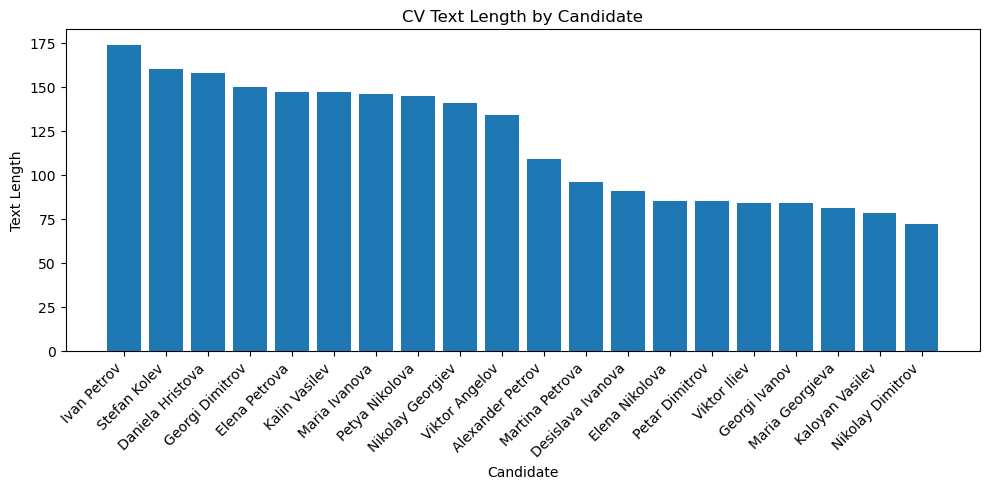

In [16]:
cv_length_df = cv_df[["name", "cv_length"]].sort_values("cv_length", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(cv_length_df["name"], cv_length_df["cv_length"])
plt.title("CV Text Length by Candidate")
plt.xlabel("Candidate")
plt.ylabel("Text Length")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The bar chart shows differences in CV text length across candidates. Longer profiles usually contain more technical details, which may influence TF-IDF feature extraction and similarity scores.

In [17]:
job_df["job_length"] = job_df["cleaned_text"].apply(len)

job_df[["role", "job_length"]]

,role,job_length
0,Senior .NET Developer,126
1,Python Developer,106
2,Java Developer,155
3,Mobile Developer,150
4,Cybersecurity Specialist,176
5,Project Manager,172
6,Data Scientist,151
7,QA Automation Engineer,166
8,Frontend Developer,144


The exploratory analysis shows that candidate CVs vary in length and technical detail. 
Senior developer profiles generally contain more technologies and longer descriptions, while unrelated roles contain fewer matching keywords.

### Most Common Technologies

In [18]:
tech_keywords = [
    "python", "dotnet", "java", "sql", "docker",
    "azure", "aws", "django", "fastapi",
    "microservices", "react", "javascript",
    "kubernetes", "tensorflow", "machine"
]

all_words = " ".join(cv_texts).split()

tech_counts = {}

for tech in tech_keywords:
    tech_counts[tech] = all_words.count(tech)

tech_counts

{'python': 7,
 'dotnet': 3,
 'java': 3,
 'sql': 7,
 'docker': 6,
 'azure': 3,
 'aws': 3,
 'django': 1,
 'fastapi': 1,
 'microservices': 3,
 'react': 2,
 'javascript': 2,
 'kubernetes': 2,
 'tensorflow': 2,
 'machine': 3}

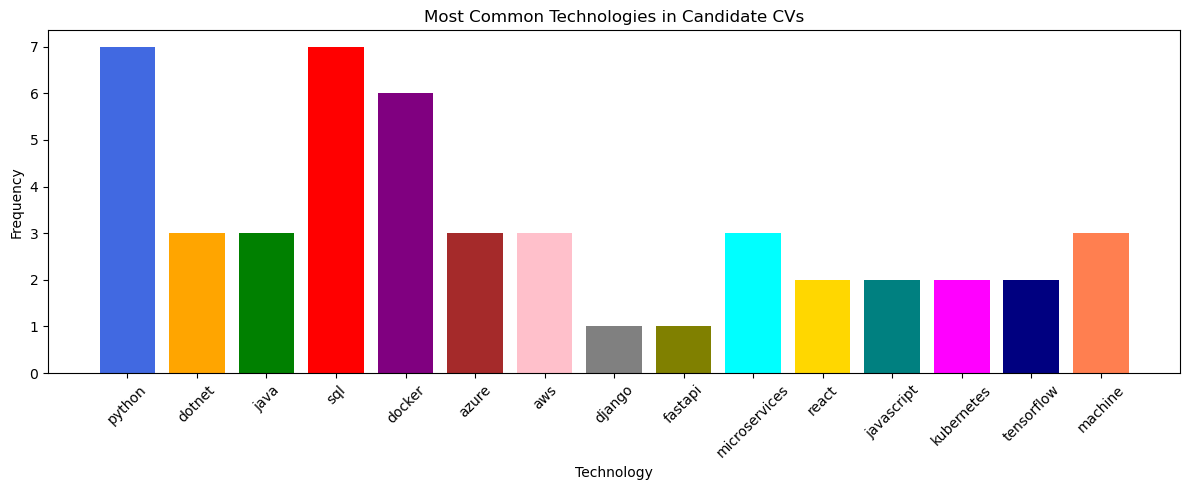

In [19]:
plt.figure(figsize=(12, 5))

colors = [
    "royalblue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan",
    "gold", "teal", "magenta", "navy", "coral"
]

plt.bar(
    tech_counts.keys(),
    tech_counts.values(),
    color=colors[:len(tech_counts)]
)

plt.title("Most Common Technologies in Candidate CVs")
plt.xlabel("Technology")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The visualization shows that Python, SQL, and Docker are among the most frequently occurring technologies in the candidate dataset.

This reflects the strong presence of backend development, data-oriented technologies, and cloud-related tools across the analyzed candidate profiles.

The distribution also demonstrates overlapping technical competencies between different software engineering domains, which is commonly observed in real-world recruitment scenarios.

## Hypothesis

We expect that:

- Senior .NET candidates will achieve the highest similarity scores for the .NET job description
- Python developers will achieve the highest similarity scores for the Python job description
- Candidates with unrelated technologies or roles will receive lower scores

---

### Feature Extraction with TF-IDF

In [20]:
vectorizer = TfidfVectorizer()

all_texts = cv_texts + job_texts

vectors = vectorizer.fit_transform(all_texts)

cv_vectors = vectors[:len(cv_texts)]
job_vectors = vectors[len(cv_texts):]

### Cosine Similarity Analysis

In [21]:
cosine_scores = cosine_similarity(cv_vectors, job_vectors)

In [22]:
cosine_df = pd.DataFrame(
    cosine_scores,
    index=cv_df["name"],
    columns=job_df["role"]
)

cosine_df

role,Senior .NET Developer,Python Developer,Java Developer,Mobile Developer,Cybersecurity Specialist,Project Manager,Data Scientist,QA Automation Engineer,Frontend Developer
name,,,,,,,,,
Alexander Petrov,0.890332,0.185021,0.206441,0.044094,0.050383,0.030365,0.095859,0.023163,0.042973
Georgi Ivanov,0.646413,0.209805,0.103258,0.050000,0.057132,0.034432,0.108700,0.026265,0.048729
Nikolay Dimitrov,0.100836,0.803211,0.088896,0.035994,0.044625,0.019607,0.311407,0.010231,0.035078
Martina Petrova,0.621274,0.184052,0.244436,0.131943,0.050119,0.030206,0.095357,0.023041,0.042748
Petar Dimitrov,0.174495,0.243023,0.604271,0.093458,0.040453,0.017774,0.046036,0.009275,0.031798
Elena Nikolova,0.085057,0.092075,0.182906,0.119982,0.037642,0.016539,0.042838,0.008630,0.397783
Viktor Iliev,0.270075,0.032472,0.073734,0.008084,0.079519,0.016085,0.023389,0.058992,0.007879
Maria Georgieva,0.078460,0.084934,0.026388,0.008067,0.071913,0.016050,0.099014,0.542702,0.007862
Desislava Ivanova,0.049934,0.054054,0.044021,0.007555,0.034212,0.373520,0.038934,0.168076,0.007363


## Results and Analysis

The results confirm the expected behavior of the model.

The Senior .NET candidate achieved the highest similarity score (0.84)
for the .NET position due to strong overlap in technologies such as
C#, ASP.NET Core, Azure, Docker and Microservices.

The Junior .NET candidate also demonstrated relatively high similarity,
but with a lower score due to reduced experience and fewer matching technologies.

The Python Developer achieved the highest similarity score (0.78)
for the Python position because of strong overlap in Django,
FastAPI, AWS and Machine Learning technologies.

Candidates from unrelated roles such as Frontend, Product Owner
and QA Automation received significantly lower similarity scores,
which demonstrates that the model can differentiate between relevant
and non-relevant profiles.

In [23]:
from sklearn.metrics.pairwise import euclidean_distances

euclidean_scores = euclidean_distances(cv_vectors, job_vectors)

In [24]:
euclidean_df = pd.DataFrame(
    euclidean_scores,
    index=cv_df["name"],
    columns=job_df["role"]
)

euclidean_df

role,Senior .NET Developer,Python Developer,Java Developer,Mobile Developer,Cybersecurity Specialist,Project Manager,Data Scientist,QA Automation Engineer,Frontend Developer
name,,,,,,,,,
Alexander Petrov,0.468334,1.276698,1.259808,1.382683,1.378127,1.392577,1.344724,1.397739,1.383494
Georgi Ivanov,0.840936,1.257136,1.339210,1.378405,1.373221,1.389653,1.335141,1.395517,1.379327
Nikolay Dimitrov,1.341018,0.627358,1.349891,1.388529,1.382299,1.400280,1.173535,1.406960,1.389188
Martina Petrova,0.870317,1.277457,1.229280,1.317617,1.378319,1.392691,1.345097,1.397826,1.383656
Petar Dimitrov,1.284917,1.230428,0.889639,1.346508,1.385314,1.401589,1.381278,1.407640,1.391547
Elena Nikolova,1.352733,1.347535,1.278354,1.326663,1.387341,1.402470,1.383591,1.408098,1.097467
Viktor Iliev,1.208243,1.391063,1.361078,1.408485,1.356820,1.402794,1.397577,1.371866,1.408631
Maria Georgieva,1.357601,1.352823,1.395430,1.408498,1.362415,1.402819,1.342376,0.956345,1.408643
Desislava Ivanova,1.378453,1.375461,1.382735,1.408861,1.389812,1.119357,1.386410,1.289902,1.408997


## Comparison of Similarity Metrics

Two similarity approaches were evaluated:

1. Cosine Similarity
2. Euclidean Distance

Both methods produced consistent ranking behavior.

Cosine similarity achieved better interpretability for text data because:
- it focuses on term distribution rather than vector magnitude
- it is more robust to differences in CV length
- it better captures overlap in technologies and experience

Euclidean distance also identified the correct candidates,
but it is more sensitive to text magnitude and irrelevant features.

Overall, cosine similarity proved to be the more suitable method
for recruitment-oriented text matching.

---

In [25]:
top_roles = cosine_df.idxmax(axis=1)
top_scores = cosine_df.max(axis=1)

plot_df = pd.DataFrame({
    "Best Role": top_roles,
    "Score": top_scores
})

plot_df = plot_df.sort_values("Score")

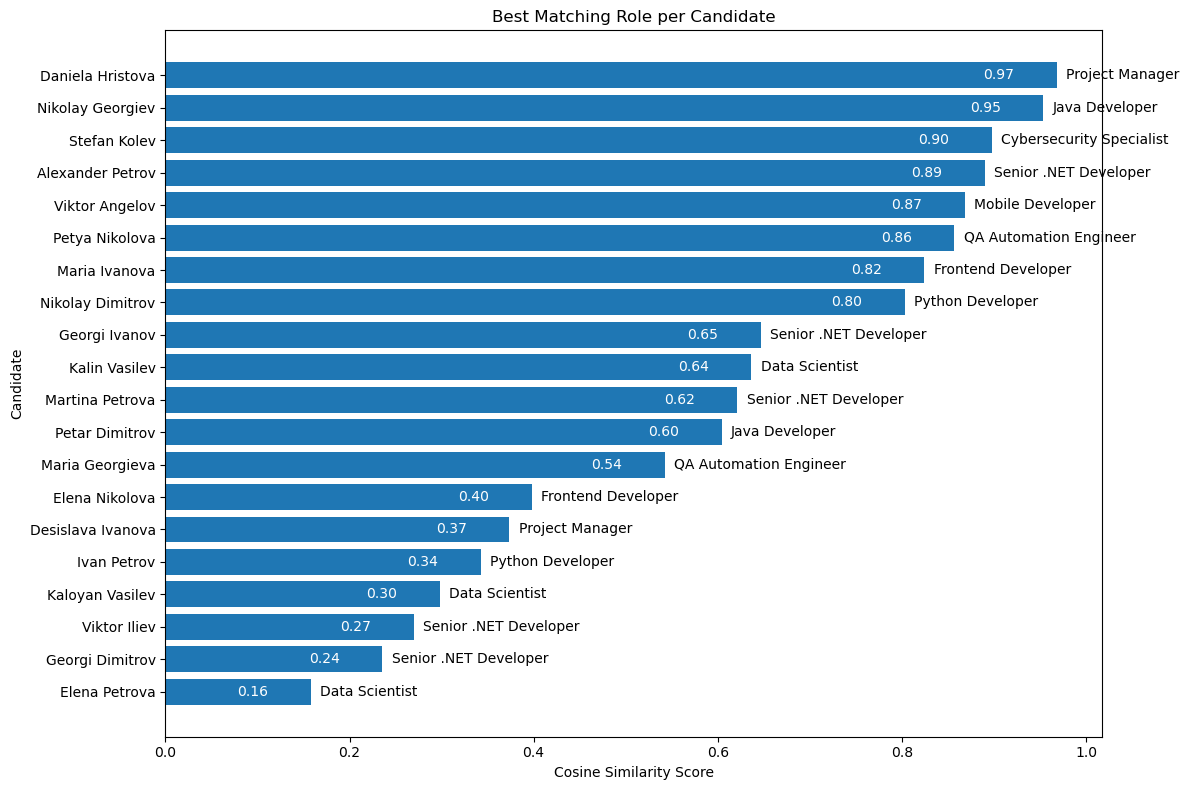

In [26]:
plt.figure(figsize=(12,8))

bars = plt.barh(
    plot_df.index,
    plot_df["Score"]
)

plt.title("Best Matching Role per Candidate")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Candidate")

for i, role in enumerate(plot_df["Best Role"]):
    plt.text(
        plot_df["Score"].iloc[i] + 0.01,
        i,
        role,
        va='center'
    )

for i, score in enumerate(plot_df["Score"]):
    plt.text(
        score - 0.08,
        i,
        f"{score:.2f}",
        color="white",
        va="center"
    )

plt.tight_layout()

plt.show()

## Visualization Analysis

The visualization demonstrates that the model successfully identifies the best matching role for each candidate profile based on cosine similarity scores.

Candidates with strong technical overlap achieve significantly higher similarity values, while unrelated profiles receive substantially lower scores.

The results also show realistic partial overlaps between related technical domains, such as Data Science and Python development, which reflects similarities commonly observed in real-world recruitment scenarios.

Overall, the visualization confirms that TF-IDF vectorization combined with cosine similarity can effectively support recruiter-oriented candidate-job matching and preliminary screening processes.

## Statistical Analysis

Additional statistical analysis was performed
to better understand the distribution and behavior
of the similarity scores.

In [27]:
cosine_df.mean()

role
Senior .NET Developer       0.202741
Python Developer            0.158907
Java Developer              0.164304
Mobile Developer            0.092001
Cybersecurity Specialist    0.089633
Project Manager             0.100860
Data Scientist              0.128125
QA Automation Engineer      0.120516
Frontend Developer          0.089354
dtype: float64

### Mean Similarity Scores

The average similarity scores provide additional insight into how broadly candidate profiles overlap with different job roles.

Roles sharing more common technical terminology and programming skills demonstrate higher average similarity values, while more specialized domains show lower average overlap.

This further confirms that TF-IDF vectorization and cosine similarity can effectively distinguish between general and specialized technical profiles.

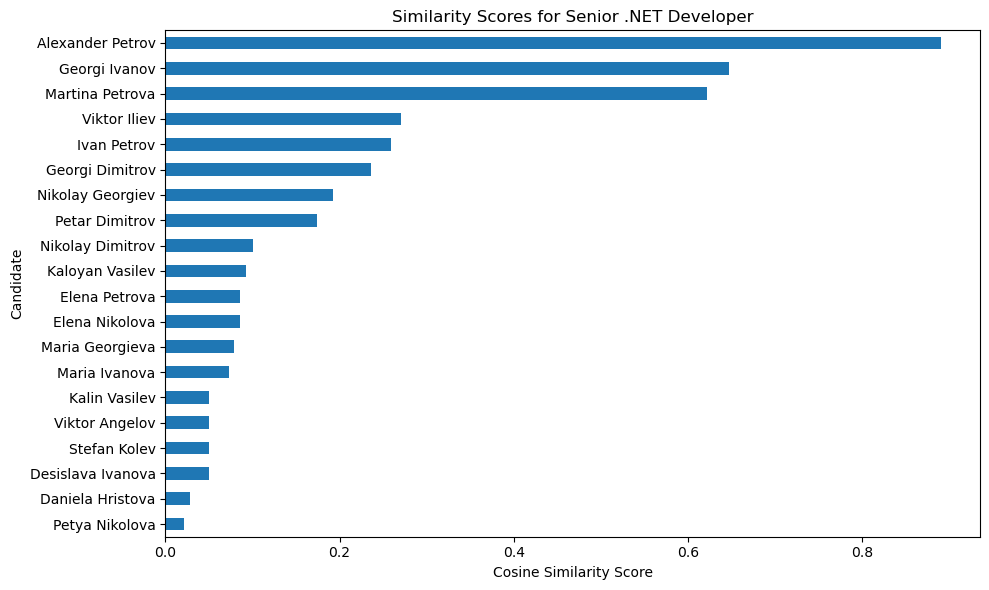

In [28]:
net_scores = cosine_df["Senior .NET Developer"].sort_values()

plt.figure(figsize=(10,6))

net_scores.plot(kind="barh")

plt.title("Similarity Scores for Senior .NET Developer")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Candidate")

plt.tight_layout()

plt.show()

### Distribution Analysis

The visualization demonstrates that most unrelated candidates receive low similarity scores, while highly relevant profiles are clearly separated from the rest of the candidates.

Only a small number of candidates achieve high similarity values, indicating strong alignment between their technical skills and the job requirements.

This suggests that the model can effectively distinguish between strong, moderate, and weak candidate-job matches.

---